In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
from multiprocessing import Process
import multiprocessing
import time

In [97]:
def Offline_policy(pkt_prob, e_prob, weight_prob, T, Bat_init1, Bat_init2, bits_init1, bits_init2, send_end):
    B_max = 2
    rmax = 1
    M = 2
    h_bad = 0.5
    h_prob = [h_bad, (1-h_bad)]
    h_val = [0.1, 1] 
    weight_val = [1, 2]

    pkt1 = [ np.random.choice([0, 1], p=[(1-pkt_prob), pkt_prob])  for t in range(T)] 
    E1 = [ np.random.choice([0, 1], p=[(1- e_prob), e_prob])  for t in range(T)] 
    h1 = [ np.random.choice(h_val, p = h_prob)  for t in range(T)] 
    wt1 = [np.random.choice(weight_val, p=[weight_prob , (1-weight_prob)]) for t in range(T)]

    pkt2 = [ np.random.choice([0, 1], p=[(1-pkt_prob), pkt_prob])  for t in range(T)] 
    E2 = [ np.random.choice([0, 1], p=[(1- e_prob), e_prob])  for t in range(T)] 
    h2 = [ np.random.choice(h_val, p = h_prob)  for t in range(T)] 
    wt2 = [np.random.choice(weight_val, p=[weight_prob , (1-weight_prob)]) for t in range(T)]

    rho1 = cp.Variable(T, nonneg =True)
    P1 = cp.Variable(T, nonneg =True)
    rho2 = cp.Variable(T, nonneg =True)
    P2 = cp.Variable(T, nonneg =True)

    B_start1 = np.zeros(T).tolist()
    rem_start1 = np.zeros(T).tolist()
    rem_end1 = np.zeros(T).tolist()
    B_end1 = np.zeros(T).tolist()

    B_start2 = np.zeros(T).tolist()
    rem_start2 = np.zeros(T).tolist()
    rem_end2 = np.zeros(T).tolist()
    B_end2 = np.zeros(T).tolist()

    wt_start1 = np.zeros(T).tolist()
    wt_start2 = np.zeros(T).tolist()

    B_start1[0] = np.minimum(E1[0] + Bat_init1, B_max)
    B_start2[0] = np.minimum(E2[0] + Bat_init2, B_max)

    if pkt1[0] == 1:
        rem_start1[0] = rmax 
        wt_start1[0] = wt1[0]
    else:
        rem_start1[0] = bits_init1
        wt_start1[0] = 1

    if pkt2[0] == 1:
        rem_start2[0] = rmax 
        wt_start2[0] = wt2[0]
    else:
        rem_start2[0] = bits_init2
        wt_start2[0] = 1
    
    rem_end1[0] = rem_start1[0] - rho1[0]
    rem_end2[0] = rem_start2[0] - rho2[0]
    B_end1[0] = B_start1[0] - P1[0]
    B_end2[0] = B_start2[0] - P2[0]

    for t in range(1, T):

        B_start1[t] =  cp.minimum(B_end1[t-1]+ E1[t], B_max)
        B_start2[t] =  cp.minimum(B_end2[t-1]+ E2[t], B_max)

        if pkt1[t] == 1:
            rem_start1[t] = rmax
            wt_start1[t] = wt1[t]
        else:
            rem_start1[t] = rem_end1[t-1]
            wt_start1[t] = wt_start1[t-1]

        if pkt2[t] == 1:
            rem_start2[t] = rmax
            wt_start2[t] = wt2[t]
        else:
            rem_start2[t] = rem_end2[t-1]
            wt_start2[t] = wt_start2[t-1]
            
        rem_end1[t] = rem_start1[t] - rho1[t]
        rem_end2[t] = rem_start2[t] - rho2[t]
        B_end1[t] = B_start1[t] - P1[t]
        B_end2[t] = B_start2[t] - P2[t]

    obj = 0
    for t in range(T):
        obj += ( wt_start1[t] *  cp.exp(-(rmax - rem_end1[t]) ) ) + ( wt_start2[t] *  cp.exp(-(rmax - rem_end2[t]) ) )
    obj_fn = (obj / (T*M))

    constraints = []

    for t in range(T):
        constraints.append(P1[t]>=0)
        constraints.append(P2[t]>=0)

        constraints.append(rho1[t]>=0)
        constraints.append(rho2[t]>=0)

        constraints.append( P1[t] <= B_start1[t])
        constraints.append( P2[t] <= B_start2[t])

        constraints.append( rho1[t] <= rem_start1[t])
        constraints.append( rho2[t] <= rem_start2[t])

        constraints.append( rho1[t] <= cp.log(1 + (h1[t]*P1[t]) ) * cp.inv_pos(cp.log(2)))
        constraints.append( rho2[t] <= cp.log(1 + (h2[t]*P2[t]) ) * cp.inv_pos(cp.log(2)) )

        constraints.append( rho1[t]+ rho2[t] <= cp.log(1 + (h1[t]*P1[t])+ (h2[t]*P2[t]) )* cp.inv_pos(cp.log(2)) )

        # constraints.append(P[t]<= (cp.exp(rem_start[t])-1)/h[t])

        # constraints.append(P1[t] <= rho1[t]*10000)
        # constraints.append(P2[t] <= rho2[t]*10000)
        constraints.append(B_end1[t] >= 0)
        constraints.append(B_end2[t] >= 0)

    objective =cp.Minimize(obj_fn)
    prob = cp.Problem(objective, constraints)
    # optimal_val = prob.solve(solver=cp.SCS, eps=1e-8,verbose =False)
    optimal_val = prob.solve(verbose =False)

    ############################################################################
    Bat_start_temp1 = [np.minimum(E1[0]+ Bat_init1, B_max)]
    Bat_start_temp2 = [np.minimum(E2[0]+ Bat_init2, B_max)]

    Bat_end_temp1 = [Bat_start_temp1[0]- P1.value[0]]
    Bat_end_temp2 = [Bat_start_temp2[0]- P2.value[0]]
    ################################################################
    if pkt1[0] == 1:
        xx1 = rmax
    else:
        xx1 = bits_init1

    if pkt2[0] == 1:
        xx2 = rmax
    else:
        xx2 = bits_init2

    bits_start_temp1 = [xx1]
    bits_start_temp2 = [xx2]

    bits_end_temp1  = [bits_start_temp1[0] - rho1.value[0]]
    bits_end_temp2  = [bits_start_temp2[0] - rho2.value[0]]

    for t in range(1, T):
        temp1 = np.minimum(Bat_end_temp1[t-1]+E1[t], B_max)
        temp2 = np.minimum(Bat_end_temp2[t-1]+E2[t], B_max)

        Bat_start_temp1.append(temp1)
        Bat_start_temp2.append(temp2)

        Bat_end_temp1.append(temp1 - P1.value[t])
        Bat_end_temp2.append(temp2 - P2.value[t])
        ###############################################################
        
        if pkt1[t] == 1:
            bits_temp1 = rmax
        else:
            bits_temp1 = bits_end_temp1[t-1] 
        
        if pkt2[t] == 1:
            bits_temp2 = rmax
        else:
            bits_temp2 = bits_end_temp2[t-1] 

            
        bits_start_temp1.append(bits_temp1)
        bits_start_temp2.append(bits_temp2)

        bits_end_temp2.append(bits_temp2 - rho2.value[t])
        bits_end_temp1.append(bits_temp1 - rho1.value[t])

    # print('final objective', pkt_prob, e_prob, weight_prob, optimal_val)
    # print('h', h1)
    # print('wt start', wt_start1)
    # print('---------------------------------------')
    # print('E', E1)
    # print('bat start', np.round(Bat_start_temp1, 3))
    # print('pow', np.round(P1.value, 3))
    # print('Bat end', np.round(Bat_end_temp1, 3))
    # print('---------------------------------------')
    # print('pkt', pkt1)
    # print('bits start', np.round(bits_start_temp1, 3))
    # print('trans bits', np.round(rho1.value, 3))
    # print('bits end', np.round(bits_end_temp1, 3))
    # print('---------------------------------------')
    
    return (optimal_val, np.round(Bat_end_temp1[-1], 3), np.round(Bat_end_temp2[-1], 3),
                np.round(bits_end_temp1[-1], 3), np.round(bits_end_temp2[-1], 3))

    # send_end.send(optimal_val)

# fin_res, Bat_end1,  Bat_end2,  Bits_end1, Bits_end2 = Offline_policy(pkt_prob=0.5, e_prob=0.8, weight_prob=0.5, 
#                                 T=20, Bat_init1=0, bits_init1=0,  Bat_init2=0, bits_init2=0, send_end = 0)
# print(fin_res, Bat_end1, Bits_end1, Bat_end2, Bits_end2)


In [98]:
# def cal_fin_res(pkt_prob, e_prob, weight_prob):
#     avg_res2 = 0
#     for yy in range(200):
#         # if yy%10 ==0:
#         #     print(yy)
#         jobs = []
#         pipe_list = []
#         for z in range(50):
#             recv_end, send_end = multiprocessing.Pipe(False)
#             p = Process(target=Offline_policy, args = (pkt_prob, e_prob, weight_prob, 20, 0, 0, 0, 0, send_end))
#             jobs.append(p)
#             pipe_list.append(recv_end)
#         for process in jobs:
#             process.start()
#         for process in jobs:
#             process.join()
#         temp = np.array([x.recv() for x in pipe_list])
#         avg_res2+= np.sum(temp)/50
#         print('done', yy, avg_res2/(yy+1))
#     avg_res2 = avg_res2/200
#     print('fin res', pkt_prob, e_prob, avg_res2)
#     return avg_res2

In [99]:
# fin_res = []
# lambda_arr = [0.5, 0.1, 1]
# for pkt_prob in lambda_arr:
#     res = cal_fin_res(pkt_prob, 0.5, 0.5)
#     fin_res.append(res)
# print(fin_res)
# np.save('offline_2_pkt_a.npy', fin_res)

In [100]:
# print(fin_res)

In [101]:
final_objective = [ ]
lambda_arr = [1]
for e_prob in lambda_arr:
    B_init1, B_init2  = 0, 0
    rho_init1, rho_init2 = 0, 0
    obj = 0
    for itr in range(1000):
        # if itr%50 ==0:
        # print(itr)
        fin_res, Bat_end1, Bat_end2,  Bits_end1, Bits_end2 = Offline_policy(0.5, e_prob, 0.5, 10, B_init1, B_init2, rho_init1, rho_init2, 0)
        obj+= fin_res
        B_init1, B_init2  = Bat_end1, Bat_end2
        rho_init1, rho_init2 = Bits_end1, Bits_end2
        if itr %10 ==0:
            print('done', itr, obj/(itr+1))

    print('res', obj/1000)
    final_objective.append(obj/500)

# np.save('one_user_offline_weight.npy', final_objective)

done 0 0.6203810115722032
done 10 0.7167129192097508
done 20 0.7291723902191041
done 30 0.7412504426949433
done 40 0.7438063077779492
done 50 0.7261834511062218
done 60 0.7259903318057436
done 70 0.7336055466572737
done 80 0.7309573183738156
done 90 0.7294168072641178
done 100 0.7374394290710125
done 110 0.7458962483633301
done 120 0.7475338646979439
done 130 0.748899894722721
done 140 0.7463706739276638
done 150 0.7455627172146782
done 160 0.7464592776483401
done 170 0.7427815930593857
done 180 0.7376972977617895
done 190 0.7380841375013425
done 200 0.7353855377928441
done 210 0.7358316800011521
done 220 0.7387633109798213
done 230 0.7384107265803329
done 240 0.737859845909983
done 250 0.7355234969055403
done 260 0.7366208158308126
done 270 0.7385987352217541
done 280 0.7384899092422064
done 290 0.7369652359547164
done 300 0.7362460914375808
done 310 0.7354793057976293
done 320 0.7341342687239312
done 330 0.7334810261233249
done 340 0.7340856921653481
done 350 0.7364877452257308
done 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def f(x):
    return np.exp(x - 4)

r_start1 = 4
step1 = 0.2
r_end1 = 4
rem_bits1 = [4, ]
cost1 = [f(4), ]
tot_bits_trans1 = [0]
bits_trans1 = [0]
temp = 0
while (r_end1 > 0):
    r_end1 = r_start1 - step1
    rem_bits1.append(r_end1)
    cost1.append(f(r_end1))

    r_start1 = r_end1
    bits_trans1.append(step1)
    temp+= step1
    tot_bits_trans1.append(temp)
time_stamp1 = np.arange(0, len(cost1), 1)

In [4]:
r_start2 = 4
step2 = 0.4
r_end2 = 4
rem_bits2 = [4, ]
cost2 = [f(4), ]
tot_bits_trans2 = [0]
bits_trans2 = [0]
temp = 0
while (r_end2 > 0):
    r_end2 = r_start2 - step2
    rem_bits2.append(r_end2)
    cost2.append(f(r_end2))

    r_start2 = r_end2
    bits_trans2.append(step2)
    temp+= step2
    tot_bits_trans2.append(temp)
time_stamp2 = np.arange(0, len(cost2), 1)

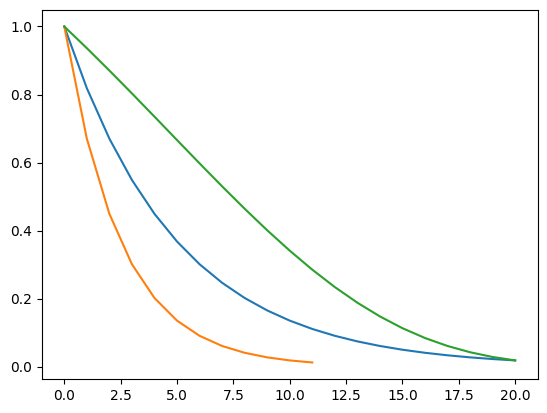

In [5]:
import numpy as np

def f(x):
    return np.exp(x - 4)

# Initial parameters
r_max = 4
r_start3 = r_max
r_end3 = r_start3
target_time = 20  # Target time stamp when r_end should be zero
rem_bits3= [r_start3]
cost3 = [f(r_start3)]
tot_bits_trans3 = [0]
bits_trans3 = [0]
temp = 0

# Generate non-linear steps that will be adjusted to sum to r_max
steps = [(r_start3 / target_time) * np.exp(0.1 * t) for t in range(1, target_time + 1)]
steps = np.array(steps) * (r_max / np.sum(steps))  # Normalize steps to sum to r_max

# Apply the steps in the loop
for step in steps:
    # Update r_end by subtracting the adjusted step
    r_end3 = max(r_start3 - step, 0)  # Ensure r_end does not go below zero
    
    # Append to lists
    rem_bits3.append(r_end3)
    
    cost3.append(f(r_end3))
    
    # Accumulate bits transferred
    temp += step
    tot_bits_trans3.append(temp)

    bits_trans3.append(step)

    # Update r_start for the next iteration
    r_start3 = r_end3

# Generate the time stamps
time_stamp3 = np.arange(0, len(cost3), 1)


plt.plot(time_stamp1, cost1)
plt.plot(time_stamp2, cost2)
plt.plot(time_stamp3, cost3)

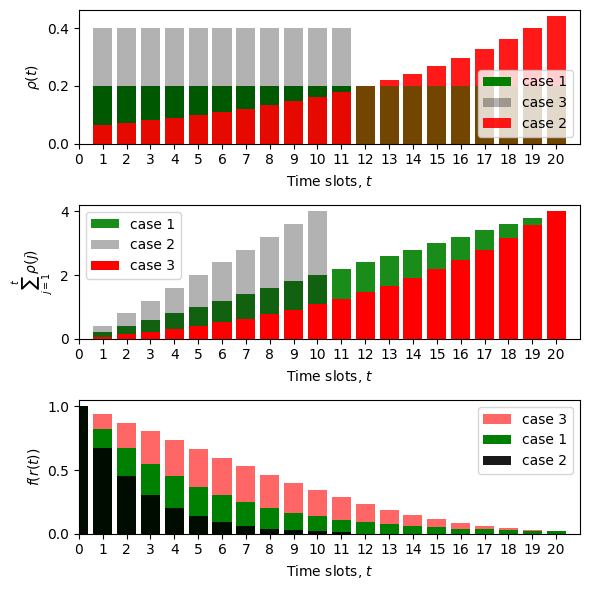

In [31]:

import matplotlib.pyplot as plt

# Create a figure with two subplots (1 row, 2 columns)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(6,6))

ax1.bar(time_stamp1, bits_trans1, color = 'g', alpha = 1, label = 'case 1')
ax1.bar(time_stamp2, bits_trans2, color = 'k', alpha = 0.3, label = 'case 3')
ax1.bar(time_stamp3, bits_trans3, color = 'r', alpha = 0.9, label = 'case 2')
ax1.bar(time_stamp1[12:], bits_trans1[12:], color = 'g', alpha = 0.5)


ax1.set_xlabel('Time slots, $t$')
ax1.set_ylabel(r'$\rho(t)$')
ax1.set_xlim(0, 21)
ax1.set_xticks(np.arange(0, 21, 1))
ax1.legend(loc='lower right')


ax2.bar(time_stamp1,tot_bits_trans1, color = 'g', alpha = 0.9, label = 'case 1')
ax2.bar(time_stamp2[:-1],tot_bits_trans2[:-1], color = 'k', alpha = 0.3, label = 'case 2')
ax2.bar(time_stamp3,tot_bits_trans3, color = 'r', alpha = 1, label = 'case 3')


ax2.set_xlabel('Time slots, $t$')
ax2.set_ylabel(r'$\sum_{j=1}^t \rho(j)$')
ax2.set_xlim(0, 21)
ax2.set_xticks(np.arange(0, 21, 1))
ax2.legend()

ax3.bar(time_stamp3, cost3, color = 'r', alpha = 0.6, label = 'case 3')
ax3.bar(time_stamp1, cost1, color = 'g', alpha = 1, label = 'case 1')
ax3.bar(time_stamp2, cost2, color = 'k', alpha = 0.9, label = 'case 2')



ax3.set_xlabel('Time slots, $t$')
ax3.set_ylabel(r'$f(r(t))$')
ax3.set_xlim(0, 21)
ax3.set_xticks(np.arange(0, 21, 1))
ax3.legend()

plt.tight_layout()
plt.show()


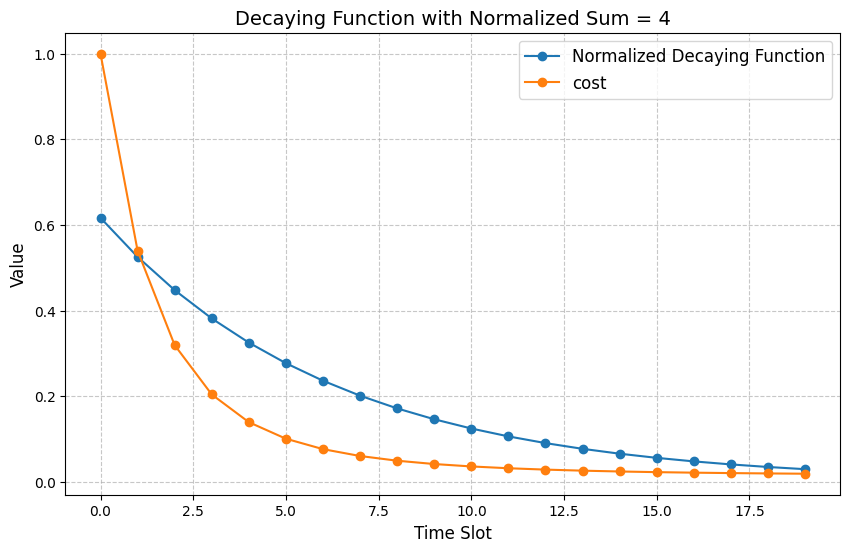

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
time_slots = 20
desired_sum = 4

# Decaying function parameters
k = 0.16  # Decay constant (adjust as needed)
time = np.arange(time_slots)
decay_values = np.exp(-k * time)
def f(x):
    return np.exp(x - 4)
# Normalize to achieve the desired sum
normalized_values = (decay_values / np.sum(decay_values)) * desired_sum

remain = [4-np.sum(normalized_values[:x]) for x in range(len(normalized_values))]
tot_sent = [np.sum(normalized_values[:x]) for x in range(len(normalized_values))]
cost_decay = [f(x) for x in remain]
# Plotting
plt.figure(figsize=(10, 6))
plt.plot(time, normalized_values, marker='o', label='Normalized Decaying Function')
# plt.plot(time, remain, marker='o', label='remain')
plt.plot(time, cost_decay, marker='o', label='cost')
# plt.plot(time, tot_sent, marker='o', label='tot_sent')
plt.title("Decaying Function with Normalized Sum = 4", fontsize=14)
plt.xlabel("Time Slot", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.show()


In [22]:
normalized_values

array([0.61655707, 0.52539528, 0.44771232, 0.38151527, 0.32510587,
       0.27703695, 0.23607532, 0.20117011, 0.17142586, 0.14607948,
       0.12448073, 0.10607548, 0.09039156, 0.07702661, 0.06563774,
       0.0559328 , 0.04766278, 0.04061555, 0.03461028, 0.02949294])

In [24]:
import pandas as pd

df = pd.DataFrame({
    "normalized_values":normalized_values,
    "remain": remain,
    "cost_decay": cost_decay,
    "tot_sent": tot_sent
})

# Save to CSV
df.to_csv("other_plot.csv", index=False)

In [16]:
time_stamp2

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])

In [17]:
cost2

[1.0,
 0.6703200460356393,
 0.4493289641172217,
 0.3011942119122022,
 0.20189651799465547,
 0.13533528323661276,
 0.09071795328941255,
 0.060810062625218,
 0.040762203978366246,
 0.02732372244729257,
 0.01831563888873419,
 0.012277339903068448]

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cvxpy as cp
from multiprocessing import Process
import multiprocessing
import time

In [5]:
M = 2
T = 5

rho1 = cp.Variable(T, nonneg =True)
P1 = cp.Variable(T, nonneg =True)
rho2 = cp.Variable(T, nonneg =True)
P2 = cp.Variable(T, nonneg =True)

B_start1 = np.zeros(T).tolist()
rem_start1 = np.zeros(T).tolist()
B_start2 = np.zeros(T).tolist()
rem_start2 = np.zeros(T).tolist()

B_start1[0] = 5
B_start2[0] = 5
rem_start1[0] = 2
rem_start2[0] = 4 

for t in range(1, T):
    B_start1[t] = B_start1[t-1] - P1[t-1]
    B_start2[t] =  B_start2[t-1] - P2[t-1]
    rem_start1[t] = rem_start1[t-1] - rho1[t-1]
    rem_start2[t] = rem_start2[t-1] - rho2[t-1]

obj = 0
for t in range(T):
    obj += (cp.exp(-(rem_start1[0] - (rem_start1[t] - rho1[t]) ) ) 
            +   cp.exp(-(rem_start2[0] - (rem_start2[t] - rho2[t])) ) )
obj_fn = (obj / (T*M))

constraints = [ ]
for t in range(T):
    constraints.append(P1[t]>=0)
    constraints.append(P2[t]>=0)
    constraints.append(rho1[t]>=0)
    constraints.append(rho2[t]>=0)
    constraints.append( P1[t] <= B_start1[t])
    constraints.append( P2[t] <= B_start2[t])
    constraints.append( rho1[t] <= rem_start1[t])
    constraints.append( rho2[t] <= rem_start2[t])

    # MAC constaints
    constraints.append(rho1[t] <= cp.log(1+P1[t]))
    constraints.append(rho2[t] <= cp.log(1+P2[t]))
    constraints.append( rho1[t]+ rho2[t] <= cp.log(1 + (P1[t])+ (P2[t]) ))

    #Other
    # constraints.append(P1[t] >= (cp.exp(rem_start1[t] * cp.log(2)) -1))
    # constraints.append(P2[t] >= (cp.exp(rem_start2[t]* cp.log(2)) -1))

objective =cp.Minimize(obj_fn)
prob = cp.Problem(objective, constraints)
# optimal_val = prob.solve(solver=cp.SCS, eps=1e-8,verbose =False)
optimal_val = prob.solve(verbose =False)


print(optimal_val)
print(np.round(P1.value, 3))
print(np.round(P2.value, 3))

print(np.sum(P1.value))
print(np.sum(P2.value))

print(np.round(rho1.value, 3))
print(np.round(rho2.value, 3))

print(np.sum(rho1.value))
print(np.sum(rho2.value))

0.1908576877704426
[2.968 1.406 0.626 0.    0.   ]
[2.602 1.351 0.679 0.369 0.   ]
4.999999997238926
4.999999997319615
[0.941 0.662 0.397 0.    0.   ]
[0.941 0.662 0.438 0.314 0.   ]
1.9999999953465484
2.3549034953505994


In [10]:
P1 = 1
P2 = 0
print(np.log2(1+0.1*P1))
print(np.log2(1+0.1*P2))
print(np.log2(1+0.1*P1+0.1*P2))



0.13750352374993502
0.0
0.13750352374993502


In [27]:

T = 5

rho1 = cp.Variable(T, nonneg =True)
P1 = cp.Variable(T, nonneg =True)


B_start1 = np.zeros(T).tolist()
rem_start1 = np.zeros(T).tolist()


B_start1[0] = 5
rem_start1[0] = 2

for t in range(1, T):
    B_start1[t] = B_start1[t-1] - P1[t-1]
    rem_start1[t] = rem_start1[t-1] - rho1[t-1]
obj = 0
for t in range(T):
    obj += (cp.exp(-(rem_start1[0] - (rem_start1[t] - rho1[t]) ) ) )
obj_fn = (obj / (T))
constraints = []
for t in range(T):
    constraints.append(P1[t]>=0)
    constraints.append(rho1[t]>=0)
    constraints.append( P1[t] <= B_start1[t])
    constraints.append( rho1[t] <= rem_start1[t])
    constraints.append( rho1[t]<= cp.log(1 + (P1[t]) ))
objective =cp.Minimize(obj_fn)
prob = cp.Problem(objective, constraints)
# optimal_val = prob.solve(solver=cp.SCS, eps=1e-8,verbose =False)
optimal_val = prob.solve(verbose =False)


print(optimal_val)
print(np.round(P1.value, 3))
print(np.sum(P1.value))
print(np.round(rho1.value, 3))
print(np.sum(rho1.value))

0.14332670278028672
[4.705 0.295 0.    0.    0.   ]
4.999999990444025
[1.741 0.259 0.    0.    0.   ]
1.9999999988896657
